  # Semantic Analysis of Domain Data for Proactive Identification of Cybersecurity Indicators                                                
                                                                          
  **Nic Recasens** — jr38088@georgiasouthern.edu                          
  **Nigel Smith** — ns15468@georgiasouthern.edu
                                                                          
  Computer Science — Georgia Southern University                          
  CSCI-7090 Data Science & Machine Learning — Spring 2026


# Combined EDA: PhishTank & Tranco
Exploratory data analysis on two datasets used in our phishing-detection pipeline:
1. **PhishTank** — verified phishing URLs (`../data/raw_input/verified_online.csv`)
2. **Tranco Top 1 M** — legitimate, popularity-ranked domains (`../data/raw_input/top-1m.csv`)

  ## Relevance Statement
                                                                          
Our project synthesizes two datasets. First, we selected PhishTank, a dataset of user-reported phishing and spam URLs, verified by Cisco Talos, with metadata curated and compiled by the dataset hosts. Additionally, we use Tranco, which aggregates the top 1 million most visited domains on the day we downloaded it. The union of these two datasets minus their intersection serves as our baseline of sites — most of which are legitimate or at the very least not flagged as malicious — while the remainder are known phishing URLs. This pairing directly mirrors the approach taken in our literature review, where papers such as Saidani et al. and Sonowal & Gunikhan rely on contrasting verified malicious samples against high-traffic legitimate baselines to train semantic classifiers. The primary strength of these two datasets, and consequently our combined dataset, is their integrity: each record is complete with no null attributes. Our wrangling and preprocessing work largely consisted of organizing and decomposing URL components into discrete features for visualization and future ML analysis.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

We have a requirement for this assignment that it run in Google Colab. As such, we pull the repo style and data from Github first.

In [2]:
import os

# Clone the repo (skip if already present)
if not os.path.exists('DS_ML_Project_ColabIntegration'):
    !git clone https://github.com/ns15468-gasou/DS_ML_Project_ColabIntegration.git

os.chdir('DS_ML_Project_ColabIntegration/Project/notebooks')
print("Working directory:", os.getcwd())

Working directory: /home/nic/DS_ML_Project_ColabIntegration/Project/notebooks/DS_ML_Project_ColabIntegration/Project/notebooks


---
# PhishTank — Verified Phishing URLs
This section analyzes the PhishTank *verified-online* feed, a curated list of confirmed phishing URLs.  
The dataset captures full URLs (scheme + host + path) along with the targeted brand and current online/offline status. [11]
**Date accessed:** 03/05/2026

In [3]:
phish = pd.read_csv('../data/raw_input/verified_online.csv')
phish['target'] = phish['target'].str.replace('&amp;', '&', regex=False)
phish.head()

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9358496,https://sgpass-fr033.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:49+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
1,9358495,https://sgpass-fr033.com/pages/asset.php,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:36+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
2,9358485,https://dervi-emprend-ec.webcindario.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:27:05+00:00,yes,2026-03-03T19:32:43+00:00,yes,Other
3,9358483,https://allegro.pl-oferta1081410.sbs,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:23:57+00:00,yes,2026-03-03T19:32:43+00:00,yes,Allegro
4,9358482,http://allegrolokalnie.oferta362639327346393.sbs,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:23:42+00:00,yes,2026-03-03T19:32:43+00:00,yes,Allegro


In [4]:
phish.shape

(56045, 8)

In [5]:
phish['submission_time'] = pd.to_datetime(phish['submission_time'])
phish['verification_time'] = pd.to_datetime(phish['verification_time'])
phish.dtypes

phish_id                           int64
url                                  str
phish_detail_url                     str
submission_time      datetime64[us, UTC]
verified                             str
verification_time    datetime64[us, UTC]
online                               str
target                               str
dtype: object

## Null / Missing Value Analysis

In [6]:
phish.isnull().sum()

phish_id             0
url                  0
phish_detail_url     0
submission_time      0
verified             0
verification_time    0
online               0
target               0
dtype: int64

In [7]:
(phish == '').sum()

phish_id             0
url                  0
phish_detail_url     0
submission_time      0
verified             0
verification_time    0
online               0
target               0
dtype: int64

## Target Brand Distribution

In [8]:
target_counts = phish['target'].value_counts().head(15)
print(target_counts)

target
Other                                  52773
Internal Revenue Service                 814
Allegro                                  654
Facebook                                 319
Microsoft                                185
Optus                                    147
DHL                                      102
AT&T                                      77
Sumitomo Mitsui Banking Corporation       75
Amazon.com                                67
Bradesco                                  62
Netflix                                   61
PayPal                                    57
Adobe                                     47
eBay, Inc.                                41
Name: count, dtype: int64


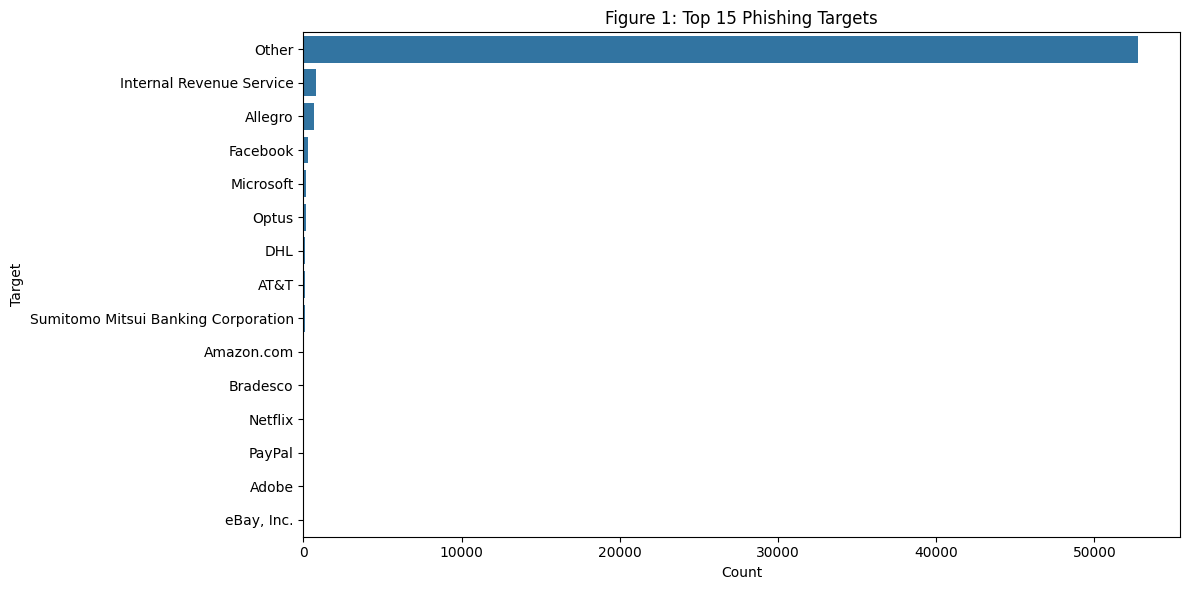

In [9]:
plt.figure(figsize=(12,6))
sns.barplot(x=target_counts.values, y=target_counts.index)
plt.title('Figure 1: Top 15 Phishing Targets')
plt.xlabel('Count')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

**Figure 1 — Interpretation:** The IRS dominates known phishing targets, followed by Allegro and Facebook. "Other" accounts for the vast majority of targets. "Other" is excluded in the below chart but note this represents a small fraction of the full dataset. "Other" representing the vast majority of data points suggests the opportunity to utilize unsupervised learning to categorize these data points based on common traits in their URLs.

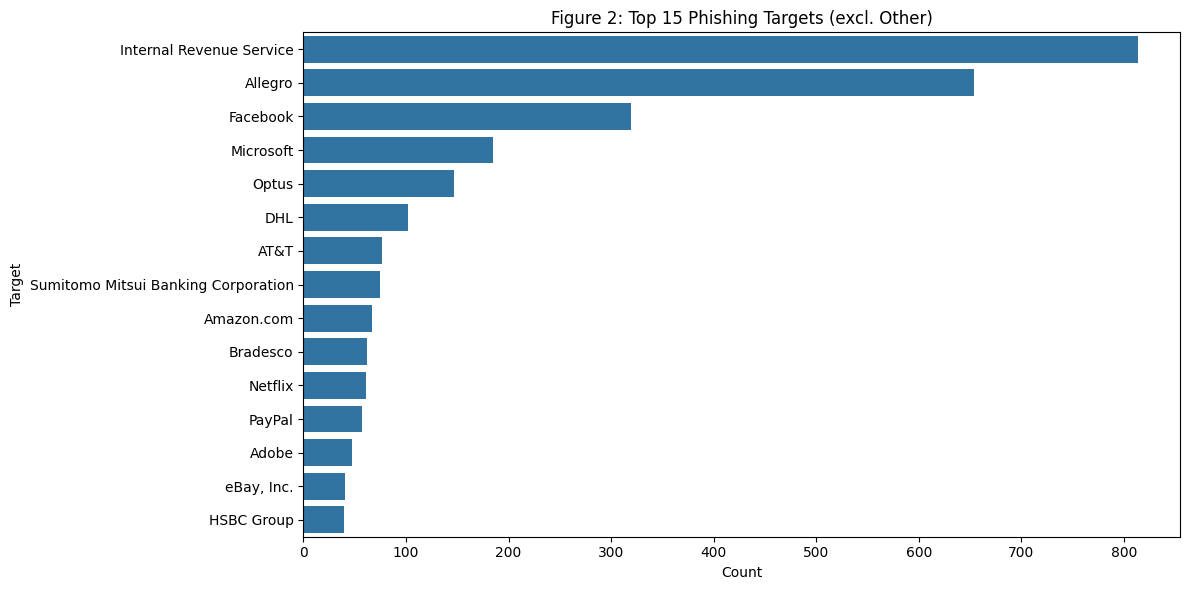

In [10]:
target_counts_filtered = phish[phish['target'] != 'Other']['target'].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=target_counts_filtered.values, y=target_counts_filtered.index)
plt.title('Figure 2: Top 15 Phishing Targets (excl. Other)')
plt.xlabel('Count')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

**Figure 2 — Interpretation:** Excluding 'Other', the IRS stands out as the most impersonated brand by a wide margin, likely due to the high-stakes nature of tax-related fraud. Financial institutions and major tech platforms round out the top targets, consistent with findings in the literature on high-value phishing campaigns. Sites where it would not be extraordinary for users to input payment information are perhaps the most logical to masquerade as. 

## Online vs Offline Breakdown

online
yes    56045
Name: count, dtype: int64


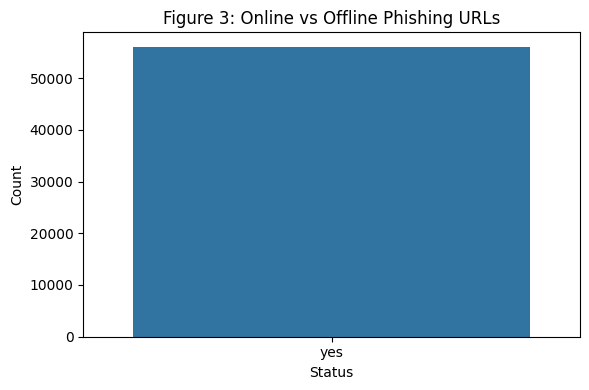

In [11]:
online_counts = phish['online'].value_counts()
print(online_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=online_counts.index, y=online_counts.values)
plt.title('Figure 3: Online vs Offline Phishing URLs')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Figure 3 — Interpretation:** This confirms the dataset represents active threats rather than historical ones, making it a strong signal for real-world phishing detection.

## Dataset Limitations
This dataset is only the verified online feed, meaning this dataset is a subset of the greater PhishTank dataset. Future work could expand to use the full dataset. This dataset would be great for clustering/unsupervised ML work: the dominance of 'Other' in the target category shows the opportunity to clean/mine this data for meaningful categorization.

## Data Dictionary — PhishTank                                          
                                                                          
  | Feature | Data Type | Description | Example |
  |---|---|---|---|                                                       
  | phish_id | int | Unique identifier for each phishing submission | 9358496 |                                                               
  | url | string | Full verified phishing URL | https://sgpass-fr033.com/ |                                                                       
  | submission_time | datetime | Timestamp when URL was submitted to PhishTank | 2026-03-03 19:50:49 |                                       
  | verification_time | datetime | Timestamp when URL was verified as phishing | 2026-03-03 20:12:24 |                                        
  | online | string | Whether the phishing URL is currently active | yes |
  | target | string | Brand or organization being impersonated | IRS |    
  | full_length | int | Total character length of the URL | 47 |          
  | host | string | Extracted hostname from the URL | sgpass-fr033.com |  
  | host_length | int | Character length of the hostname | 16 |           
  | path_depth | int | Number of path segments in the URL | 2 |           
  | dot_count | int | Number of dots in the full URL | 3 |                
  | hyphen_count | int | Number of hyphens in the full URL | 2 |          
  | digit_count | int | Number of digit characters in the URL | 4 |       
  | digit_ratio | float | Proportion of URL characters that are digits |0.085 |                                                                 
  | subdomain_depth | int | Number of dots in the hostname (proxy for subdomain nesting) | 1 |

## URL Structure Analysis
Feature engineering and visualizations on URL structure — length, hosting domains, path depth, and character composition.

In [12]:
phish['host'] = phish['url'].apply(lambda x: urlparse(x).netloc.lower())
phish['full_length'] = phish['url'].str.len()
phish['host_length'] = phish['host'].str.len()
phish['path'] = phish['url'].apply(lambda x: urlparse(x).path)
phish['path_depth'] = phish['path'].apply(lambda p: p.strip('/').count('/') + 1 if p.strip('/') else 0)
phish['has_path'] = (phish['path'].str.strip('/') != '').astype(int)
phish['tld_ext'] = phish['host'].str.rsplit('.', n=1).str[-1]
phish['dot_count'] = phish['url'].str.count(r'\.')
phish['hyphen_count'] = phish['url'].str.count('-')
phish['digit_count'] = phish['url'].str.count(r'\d')
phish['digit_ratio'] = phish['digit_count'] / phish['full_length']
phish['subdomain_depth'] = phish['host'].str.count(r'\.')

print("PhishTank — Raw Features") 
phish[['full_length', 'host_length', 'path_depth', 'dot_count', 'hyphen_count',
    'digit_count', 'digit_ratio', 'subdomain_depth']].describe()

PhishTank — Raw Features


,full_length,host_length,path_depth,dot_count,hyphen_count,digit_count,digit_ratio,subdomain_depth
count,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000
mean,60.922866,19.275511,1.387457,1.974413,0.797127,6.373254,0.075019,1.768454
std,166.386061,12.977728,1.582218,1.025418,1.391185,24.004548,0.096198,0.583268
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,23.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,38.000000,16.000000,1.000000,2.000000,0.000000,1.000000,0.045455,2.000000
75%,62.000000,25.000000,2.000000,2.000000,1.000000,8.000000,0.107143,2.000000
max,25523.000000,147.000000,18.000000,67.000000,50.000000,3413.000000,0.796610,9.000000


In [13]:
clip_threshold = 0.98                                                                             
phish_clipped = phish[['full_length', 'host_length', 'path_depth', 'dot_count', 'hyphen_count',
                       'digit_count', 'digit_ratio', 'subdomain_depth']].apply(
    lambda col: col.clip(upper=col.quantile(clip_threshold)))
print("PhishTank — Features Clipped at 98th Percentile")
phish_clipped.describe()   

PhishTank — Features Clipped at 98th Percentile


,full_length,host_length,path_depth,dot_count,hyphen_count,digit_count,digit_ratio,subdomain_depth
count,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000
mean,57.060451,19.012561,1.378678,1.930181,0.739763,5.577661,0.074185,1.760764
std,47.987538,11.943231,1.547480,0.731294,1.030938,8.012756,0.093138,0.553896
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,23.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,38.000000,16.000000,1.000000,2.000000,0.000000,1.000000,0.045455,2.000000
75%,62.000000,25.000000,2.000000,2.000000,1.000000,8.000000,0.107143,2.000000
max,190.000000,60.000000,5.000000,4.000000,4.000000,30.000000,0.370968,3.000000


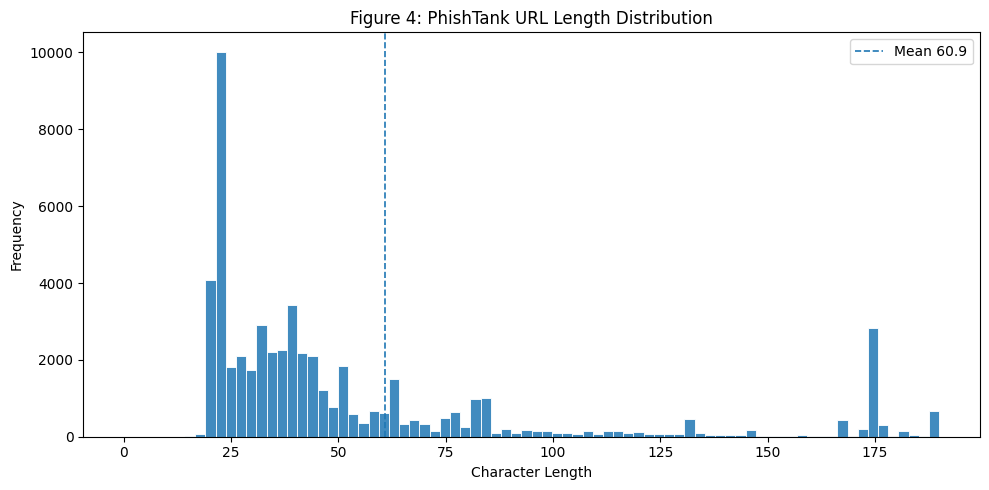

In [14]:
# URL length distribution (clipped to 98th percentile)
plt.figure(figsize=(10, 5))
sns.histplot(phish['full_length'], bins=80, edgecolor='white', alpha=0.85,
             binrange=(0, phish['full_length'].quantile(0.98)))
plt.axvline(phish['full_length'].mean(), ls='--', lw=1.2,
            label=f'Mean {phish["full_length"].mean():.1f}')
plt.title('Figure 4: PhishTank URL Length Distribution')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.legend()
plt.show()

**Figure 4 — Interpretation:** PhishTank URL lengths are right-skewed with a long tail of very long URLs, clipped here at the 98th percentile for readability. The mean length is notably higher than Tranco domains (below), suggesting phishing URLs tend to be more verbose.

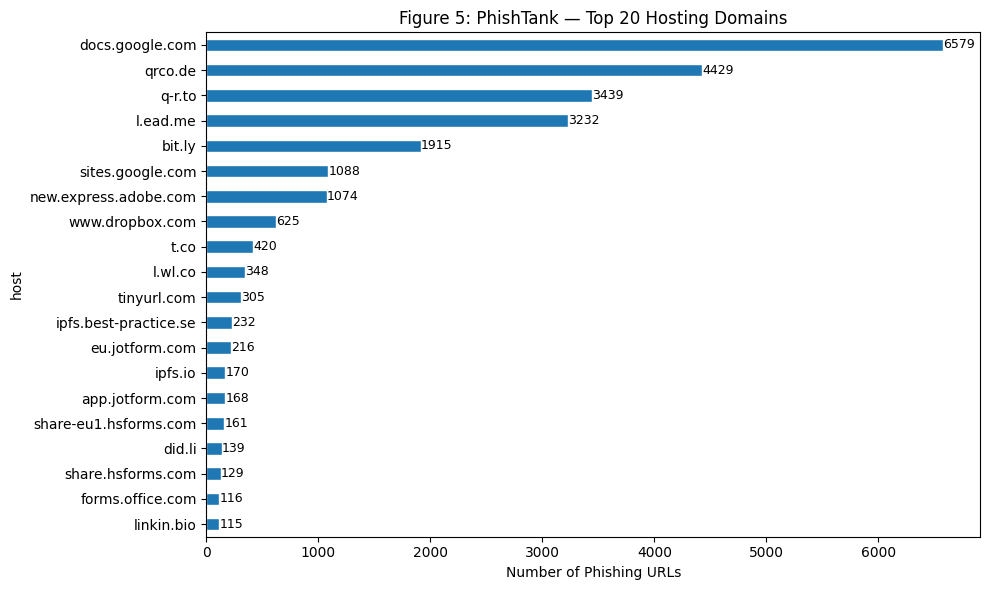

In [15]:
# Top 20 hosting domains
host_counts = phish['host'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
host_counts.plot.barh(ax=ax, edgecolor='white')
ax.set_title('Figure 5: PhishTank — Top 20 Hosting Domains')
ax.set_xlabel('Number of Phishing URLs')
ax.invert_yaxis()

for i, v in enumerate(host_counts):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Figure 5 — Interpretation:** A significant portion of phishing URLs are hosted on a small number of major platforms such as web hosting providers and cloud services. This indicates attackers frequently exploit the perceived legitimacy of established infrastructure, making domain-level detection alone insufficient.

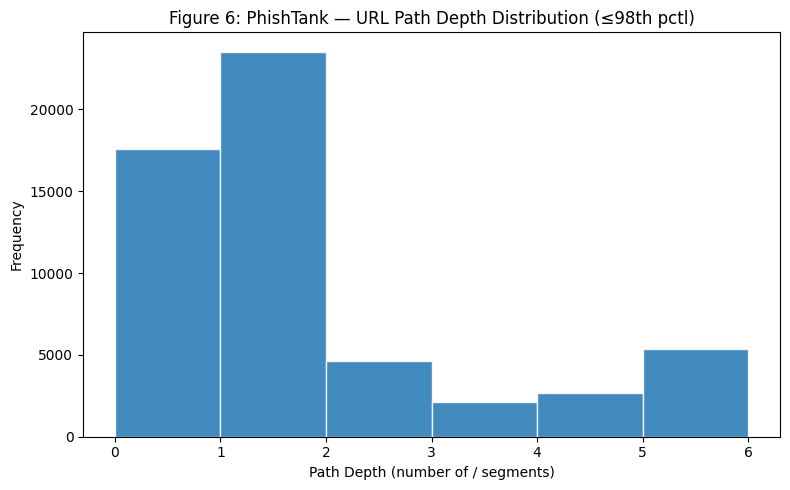

In [16]:
# Path depth distribution (clipped to 98th percentile)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(phish['path_depth'],
        bins=range(0, int(phish['path_depth'].quantile(0.98)) + 2),
        edgecolor='white', alpha=0.85)
ax.set_title('Figure 6: PhishTank — URL Path Depth Distribution (≤98th pctl)')
ax.set_xlabel('Path Depth (number of / segments)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Figure 6 — Interpretation:** Most phishing URLs have shallow path depths of 1-2 segments, though a notable portion have deeper paths. Deeper paths can indicate more sophisticated phishing kits with multiple redirect layers, which aligns with literature noting that complex URL structures are a common obfuscation technique. That said, there is not a strong sign that deeper or shallower paths are signs on their own of legitimacy or vice versa.

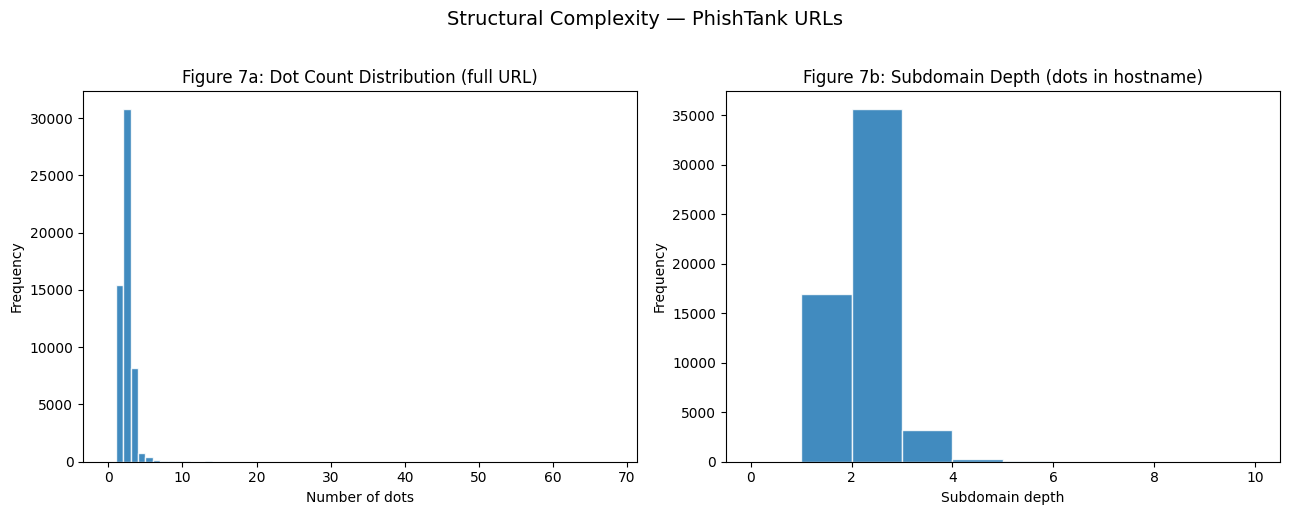

In [17]:
# Structural complexity: dot count & subdomain depth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(phish['dot_count'], bins=range(0, phish['dot_count'].max() + 2),
             edgecolor='white', alpha=0.85)
axes[0].set_title('Figure 7a: Dot Count Distribution (full URL)')
axes[0].set_xlabel('Number of dots')
axes[0].set_ylabel('Frequency')

axes[1].hist(phish['subdomain_depth'], bins=range(0, phish['subdomain_depth'].max() + 2),
             edgecolor='white', alpha=0.85)
axes[1].set_title('Figure 7b: Subdomain Depth (dots in hostname)')
axes[1].set_xlabel('Subdomain depth')
axes[1].set_ylabel('Frequency')

fig.suptitle('Structural Complexity — PhishTank URLs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Figures 7a/7b — Interpretation:** PhishTank URLs show higher dot counts than typical domains, reflecting deeper subdomain nesting. Subdomain depth follows a similar pattern, with many URLs using 2 or more subdomains, a common tactic to make malicious domains appear affiliated with legitimate ones (e.g. amazon.phish.com).

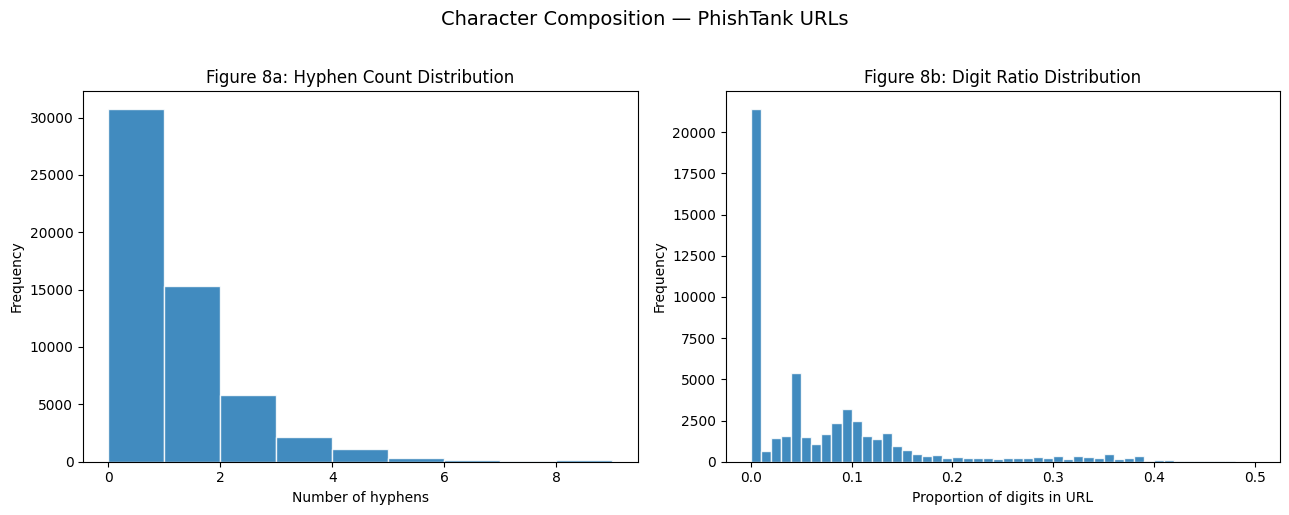

In [18]:
# Character composition: hyphens & digit ratio
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(phish['hyphen_count'], bins=range(0, 10),
             edgecolor='white', alpha=0.85)
axes[0].set_title('Figure 8a: Hyphen Count Distribution')
axes[0].set_xlabel('Number of hyphens')
axes[0].set_ylabel('Frequency')

axes[1].hist(phish['digit_ratio'], bins=50,
              edgecolor='white', alpha=0.85, range=(0, 0.5))
axes[1].set_title('Figure 8b: Digit Ratio Distribution')
axes[1].set_xlabel('Proportion of digits in URL')
axes[1].set_ylabel('Frequency')

fig.suptitle('Character Composition — PhishTank URLs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Figures 8a/8b — Interpretation:** Hyphens are rare but present in a notable subset of phishing URLs, sometimes used to mimic legitimate domains (e.g. paypal-secure.com). Digit ratios are low overall but with outliers — URLs with unusually high digit ratios may indicate algorithmically generated domains, which is a key signal for our planned ML analysis. We would additionally like to look into domains containing numbers masquerading as letters, e.g., '1' in place of an 'l', say "netf1ix.com".

---
# Tranco — Top 1 M Legitimate Domains
This section analyzes the Tranco Top-1M ranking, an aggregated popularity list of legitimate domains.  
Unlike PhishTank URLs, Tranco entries are bare domains (no scheme or path), making structural features directly comparable at the hostname level.
Cisco provides resources to help massage all the data coming in [10].

**List ID:** 6GPNX &nbsp;|&nbsp; **Date accessed:** 03/05/2026

  ## Data Dictionary — Tranco
                                                                          
  | Feature | Data Type | Description | Example |
  |---|---|---|---|                                                       
  | rank | int | Popularity rank (1 = most visited) | 1 |
  | domain | string | Registered domain name | google.com |
  | tld | string | Top-level domain extracted from domain | com |         
  | domain_length | int | Character length of the domain | 10 |           
  | dot_count | int | Number of dots in the domain | 1 |                  
  | hyphen_count | int | Number of hyphens in the domain | 0 |            
  | digit_count | int | Number of digit characters in the domain | 0 |    
  | digit_ratio | float | Proportion of domain characters that are digits| 0.0 |  

In [19]:
tranco = pd.read_csv('../data/raw_input/top-1m.csv', header=None, names=['rank', 'domain'])
tranco.head()

,rank,domain
0,1,google.com
1,2,microsoft.com
2,3,gtld-servers.net
3,4,facebook.com
4,5,mail.ru


In [20]:
tranco.shape

(1000000, 2)

In [21]:
tranco.dtypes

rank      int64
domain      str
dtype: object

## Null / Missing Value Analysis

In [22]:
tranco.isnull().sum()

(tranco == '').sum()

rank      0
domain    0
dtype: int64

## Duplicate Check

In [23]:
duplicateDomains = tranco['domain'].duplicated().sum()
duplicateRanks = tranco['rank'].duplicated().sum()
print(f'Duplicate domains: {duplicateDomains}')
print(f'Duplicate ranks: {duplicateRanks}')

Duplicate domains: 0
Duplicate ranks: 0


## TLD Distribution

In [24]:
tranco['tld'] = tranco['domain'].str.split('.').str[-1]
tld_counts = tranco['tld'].value_counts().head(15)
print(tld_counts)

tld
com    431460
net     51741
ru      42879
org     39514
de      26817
uk      22815
br      17524
jp      16280
in      12403
fr      11433
io      10800
nl      10241
it      10051
xyz      9407
pl       9054
Name: count, dtype: int64


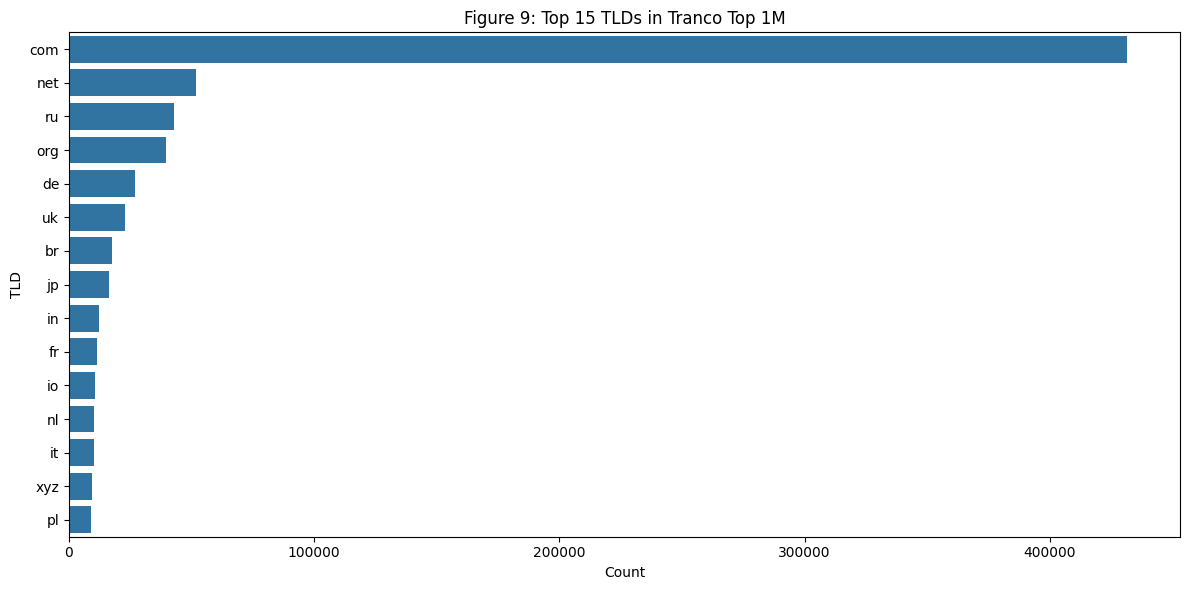

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(x=tld_counts.values, y=tld_counts.index)
plt.title('Figure 9: Top 15 TLDs in Tranco Top 1M')
plt.xlabel('Count')
plt.ylabel('TLD')
plt.tight_layout()
plt.show()

**Figure 9 — Interpretation:** .com dominates the Tranco top 1M as expected, reflecting its status as the default TLD for established businesses. Country-code TLDs like .ru, .de, and .br are also well-represented, indicating the dataset has strong international coverage which broadens the generalizability of our baseline.

## Domain Length Distribution

In [26]:
tranco['domain_length'] = tranco['domain'].str.len()
print(tranco['domain_length'].describe())

count    1000000.000000
mean          13.739423
std            4.346079
min            4.000000
25%           11.000000
50%           13.000000
75%           16.000000
max           75.000000
Name: domain_length, dtype: float64


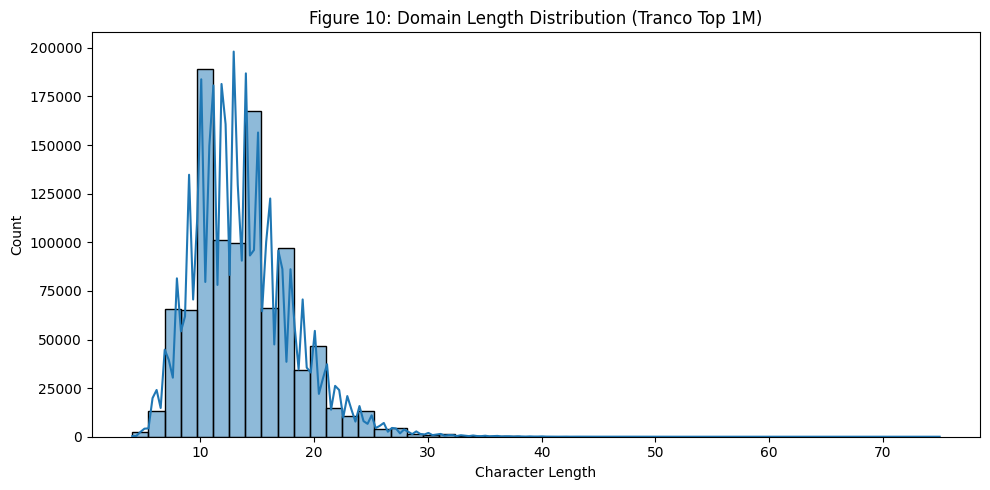

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(tranco['domain_length'], bins=50, kde=True)
plt.title('Figure 10: Domain Length Distribution (Tranco Top 1M)')
plt.xlabel('Character Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Figure 10 — Interpretation:** Tranco domain lengths cluster tightly between 8-20 characters with a roughly normal distribution, reflecting the tendency of legitimate established domains to be short and memorable. This contrasts sharply with PhishTank URL lengths, providing a potentially strong discriminating feature for classification.

## Structural & Character Features
Dot counts, subdomain depth, hyphens, and digit ratios for Tranco domains.

In [28]:
tranco['dot_count'] = tranco['domain'].str.count(r'\.')
tranco['hyphen_count'] = tranco['domain'].str.count('-')
tranco['digit_count'] = tranco['domain'].str.count(r'\d')
tranco['digit_ratio'] = tranco['digit_count'] / tranco['domain_length']
tranco['subdomain_depth'] = tranco['domain'].str.count(r'\.')

tranco[['domain_length', 'dot_count', 'hyphen_count', 'digit_count', 'digit_ratio', 'subdomain_depth']].describe()

,domain_length,dot_count,hyphen_count,digit_count,digit_ratio,subdomain_depth
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,13.739423,1.107173,0.121737,0.275257,0.022526,1.107173
std,4.346079,0.314686,0.410282,0.936712,0.075484,0.314686
min,4.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,11.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,13.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,16.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,75.000000,3.000000,11.000000,56.000000,0.933333,3.000000


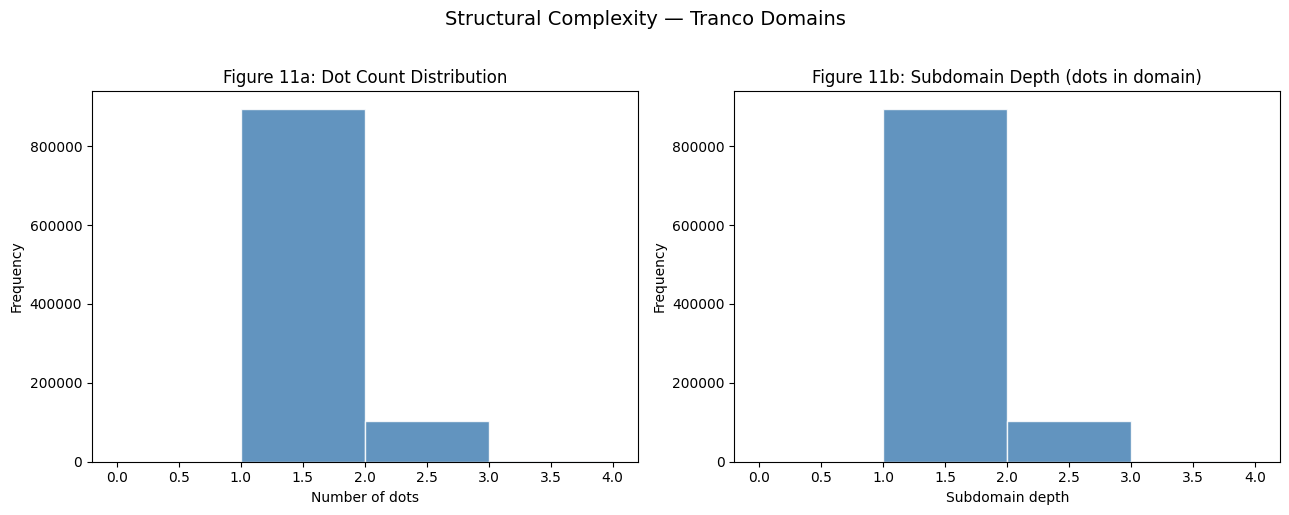

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins_dots = range(0, tranco['dot_count'].max() + 2)
axes[0].hist(tranco['dot_count'], bins=bins_dots, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Figure 11a: Dot Count Distribution')
axes[0].set_xlabel('Number of dots')
axes[0].set_ylabel('Frequency')

bins_sub = range(0, tranco['subdomain_depth'].max() + 2)
axes[1].hist(tranco['subdomain_depth'], bins=bins_sub, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Figure 11b: Subdomain Depth (dots in domain)')
axes[1].set_xlabel('Subdomain depth')
axes[1].set_ylabel('Frequency')

fig.suptitle('Structural Complexity — Tranco Domains', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Figures 11a/11b — Interpretation:** Tranco domains predominantly have 1-2 dots, corresponding to simple registered domains with at most one subdomain level. The low subdomain depth compared to PhishTank suggests subdomain nesting is a meaningful feature for distinguishing phishing from legitimate traffic.

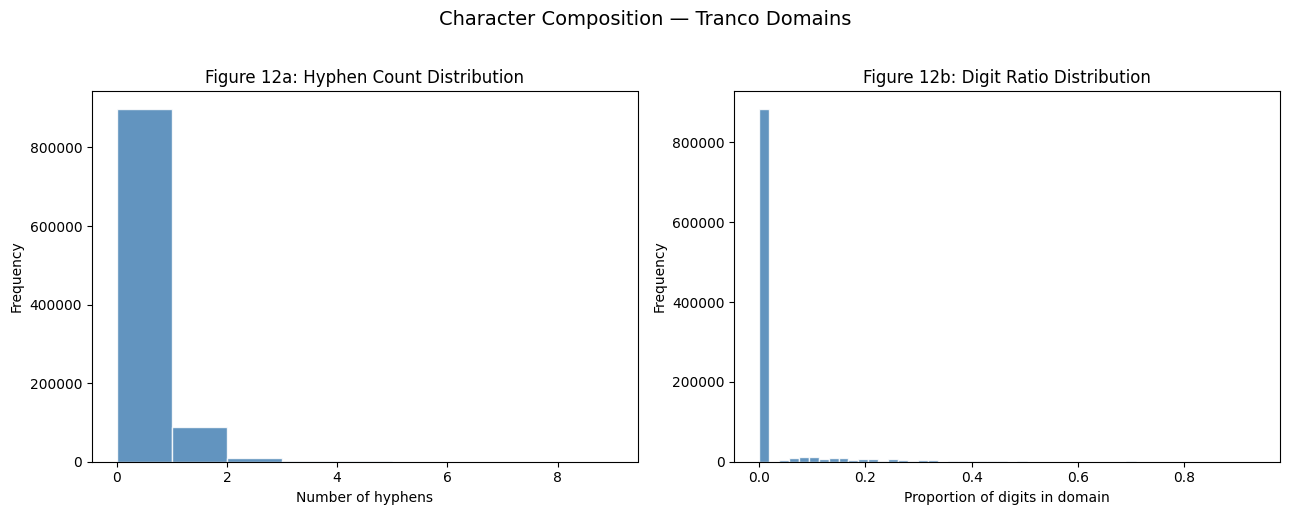

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(tranco['hyphen_count'], bins=range(0, 10), color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Figure 12a: Hyphen Count Distribution')
axes[0].set_xlabel('Number of hyphens')
axes[0].set_ylabel('Frequency')

axes[1].hist(tranco['digit_ratio'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Figure 12b: Digit Ratio Distribution')
axes[1].set_xlabel('Proportion of digits in domain')
axes[1].set_ylabel('Frequency')

fig.suptitle('Character Composition — Tranco Domains', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Figures 12a/12b — Interpretation:** Tranco domains rarely contain hyphens and have very low digit ratios, reinforcing that legitimate popular domains tend to be clean alphanumeric strings. The contrast with PhishTank on both metrics supports their use as discriminating features in downstream ML modeling.

---
# Cross-Dataset Analysis

## PhishTank / Tranco Overlap

In [31]:
phish['domain'] = phish['url'].apply(lambda x:
    urlparse(x).netloc.lower().replace('www.', '', 1))

tranco_domains = set(tranco['domain'].str.lower())
overlap = phish['domain'].isin(tranco_domains).sum()
print(f'Phishing URLs whose domain appears in Tranco Top 1M: {overlap} / {len(phish)} ({overlap/len(phish)*100:.2f}%)')

Phishing URLs whose domain appears in Tranco Top 1M: 13662 / 56045 (24.38%)


In [32]:
print(f"Tranco: {len(tranco):,} legitimate domains (ranked by popularity)")
print(f"PhishTank: {len(phish):,} verified phishing URLs")
print(f"Overlap: {overlap:,} phishing domains found in Tranco top 1M ({overlap/len(phish)*100:.2f}%)")
print("\nNotes:\n- Tranco aggregates multiple blocklists/popularity sources; high rank != guaranteed safe\n- PhishTank is a snapshot of verified-online phishing URLs, not exhaustive\n- Overlap may reflect compromised legitimate domains or shared hosting infrastructure")


Tranco: 1,000,000 legitimate domains (ranked by popularity)
PhishTank: 56,045 verified phishing URLs
Overlap: 13,662 phishing domains found in Tranco top 1M (24.38%)

Notes:
- Tranco aggregates multiple blocklists/popularity sources; high rank != guaranteed safe
- PhishTank is a snapshot of verified-online phishing URLs, not exhaustive
- Overlap may reflect compromised legitimate domains or shared hosting infrastructure


## Summary Comparison Table
Side-by-side comparison of Tranco legitimate domains vs PhishTank phishing URLs.

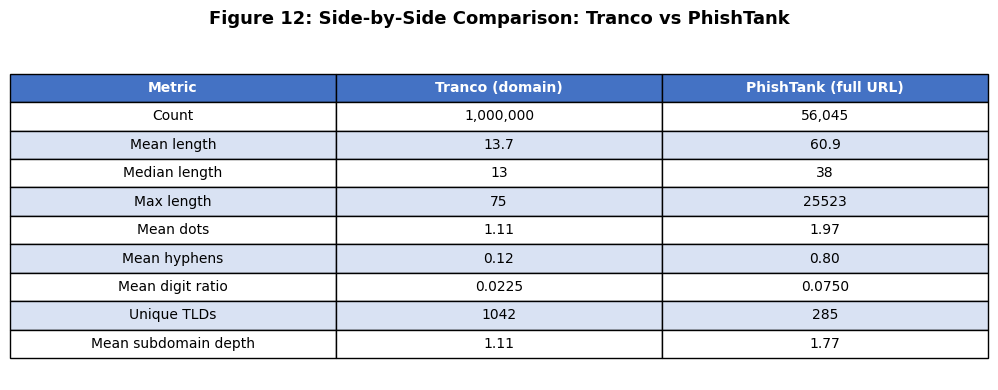

In [33]:
summary_data = {
    "Metric": [
        "Count", "Mean length", "Median length", "Max length",
        "Mean dots", "Mean hyphens", "Mean digit ratio",
        "Unique TLDs", "Mean subdomain depth"
    ],
    "Tranco (domain)": [
        f"{len(tranco):,}",
        f"{tranco['domain_length'].mean():.1f}",
        f"{tranco['domain_length'].median():.0f}",
        f"{tranco['domain_length'].max()}",
        f"{tranco['dot_count'].mean():.2f}",
        f"{tranco['hyphen_count'].mean():.2f}",
        f"{tranco['digit_ratio'].mean():.4f}",
        f"{tranco['tld'].nunique()}",
        f"{tranco['subdomain_depth'].mean():.2f}",
    ],
    "PhishTank (full URL)": [
        f"{len(phish):,}",
        f"{phish['full_length'].mean():.1f}",
        f"{phish['full_length'].median():.0f}",
        f"{phish['full_length'].max()}",
        f"{phish['dot_count'].mean():.2f}",
        f"{phish['hyphen_count'].mean():.2f}",
        f"{phish['digit_ratio'].mean():.4f}",
        f"{phish['tld_ext'].nunique()}",
        f"{phish['subdomain_depth'].mean():.2f}",
    ],
}
summary_tbl = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
tbl = ax.table(cellText=summary_tbl.values, colLabels=summary_tbl.columns,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items(): # From Datacamp [9], alternating row colors and header styling
    if row == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#D9E2F3")
ax.set_title("Figure 12: Side-by-Side Comparison: Tranco vs PhishTank", fontsize=13,
             fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

**Figure 12 — Interpretation:** Side-by-side comparison shows systematic structural differences between PhishTank and Tranco. PhishTank URLs are longer, have higher hyphen counts, and greater subdomain depth on average. These differences are consistent across the dataset and suggest that lexical URL features alone carry meaningful signal for phishing detection.

## Correlation Heatmaps
Pearson correlation among the numerical structural features for each dataset.  
Since Tranco entries are bare domains and PhishTank entries are full URLs, each heatmap uses the features native to its dataset.

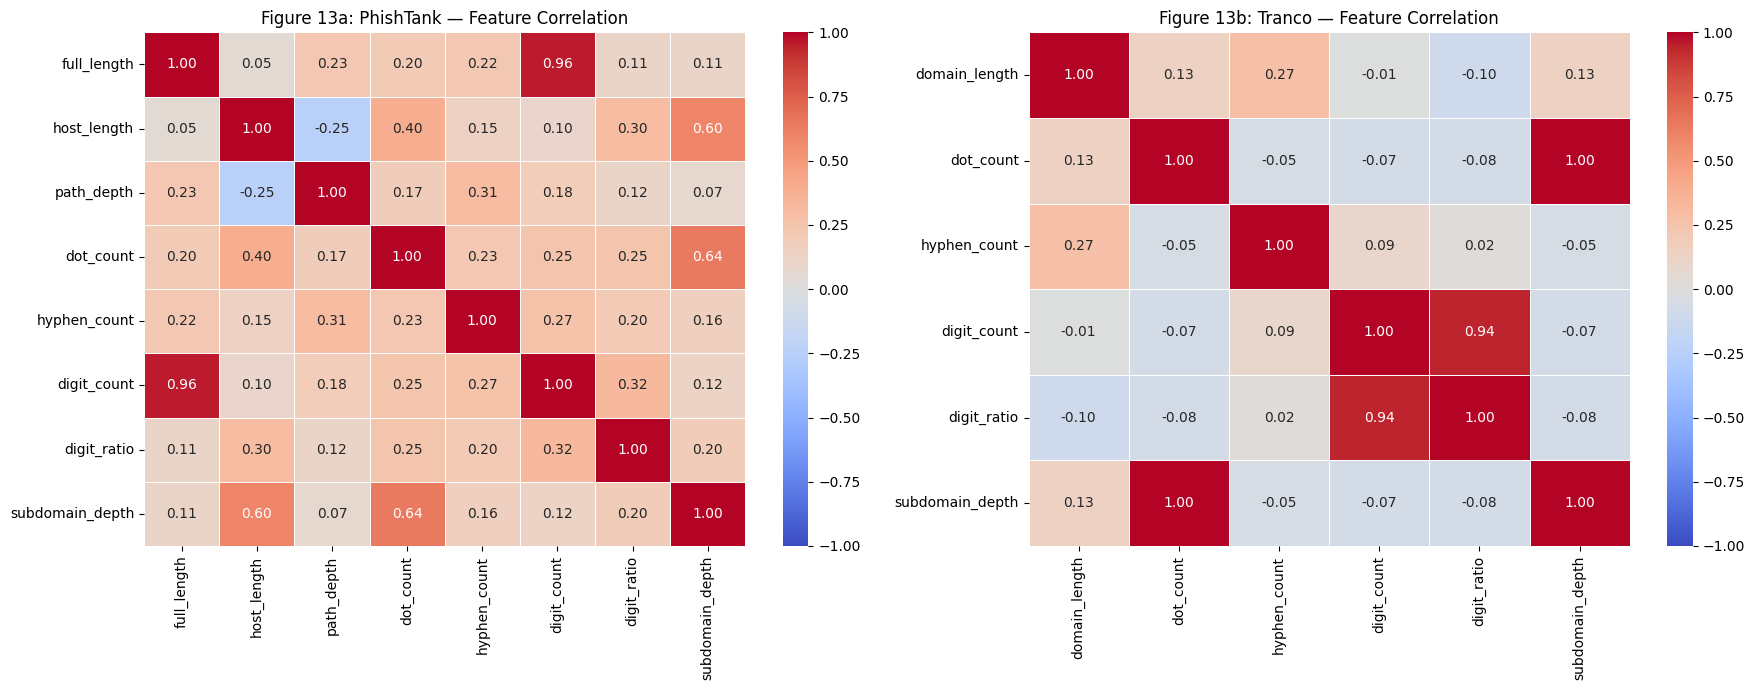


PhishTank — Top 3 strongest correlations:
  full_length ↔ digit_count: r = 0.957
  dot_count ↔ subdomain_depth: r = 0.643
  host_length ↔ subdomain_depth: r = 0.599

Tranco — Top 3 strongest correlations:
  dot_count ↔ subdomain_depth: r = 1.000
  digit_count ↔ digit_ratio: r = 0.945
  domain_length ↔ hyphen_count: r = 0.274


In [34]:
phish_num = phish[['full_length', 'host_length', 'path_depth', 'dot_count',
                   'hyphen_count', 'digit_count', 'digit_ratio', 'subdomain_depth']]
tranco_num = tranco[['domain_length', 'dot_count', 'hyphen_count',
                     'digit_count', 'digit_ratio', 'subdomain_depth']]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PhishTank heatmap
corr_phish = phish_num.corr()
sns.heatmap(corr_phish, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Figure 13a: PhishTank — Feature Correlation', fontsize=12)

# Tranco heatmap
corr_tranco = tranco_num.corr()
sns.heatmap(corr_tranco, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Figure 13b: Tranco — Feature Correlation', fontsize=12)

plt.tight_layout()
plt.show()

# Interpret strongest correlations for each dataset
for name, corr in [('PhishTank', corr_phish), ('Tranco', corr_tranco)]:
    # Upper triangle only (no duplicates / diagonal)
    mask = pd.np.triu(pd.np.ones(corr.shape), k=1).astype(bool) if hasattr(pd, 'np') else __import__('numpy').triu(__import__('numpy').ones(corr.shape), k=1).astype(bool)
    pairs = corr.where(mask).stack().reset_index()
    pairs.columns = ['Feature A', 'Feature B', 'r']
    pairs['abs_r'] = pairs['r'].abs()
    top = pairs.nlargest(3, 'abs_r')
    print(f"\n{name} — Top 3 strongest correlations:")
    for _, row in top.iterrows():
        print(f"  {row['Feature A']} ↔ {row['Feature B']}: r = {row['r']:.3f}")

**Figures 13a/13b — Interpretation:** The PhishTank correlation heatmap reveals strong positive correlation between full URL length and host length, as well as dot count and subdomain depth — as expected since longer URLs tend to have more components. Tranco shows weaker inter-feature correlations overall, suggesting its domains are structurally more uniform and simple.

## Scatter Plots — Feature Relationships
Pair plots of key structural features for each dataset to visualize bivariate relationships.

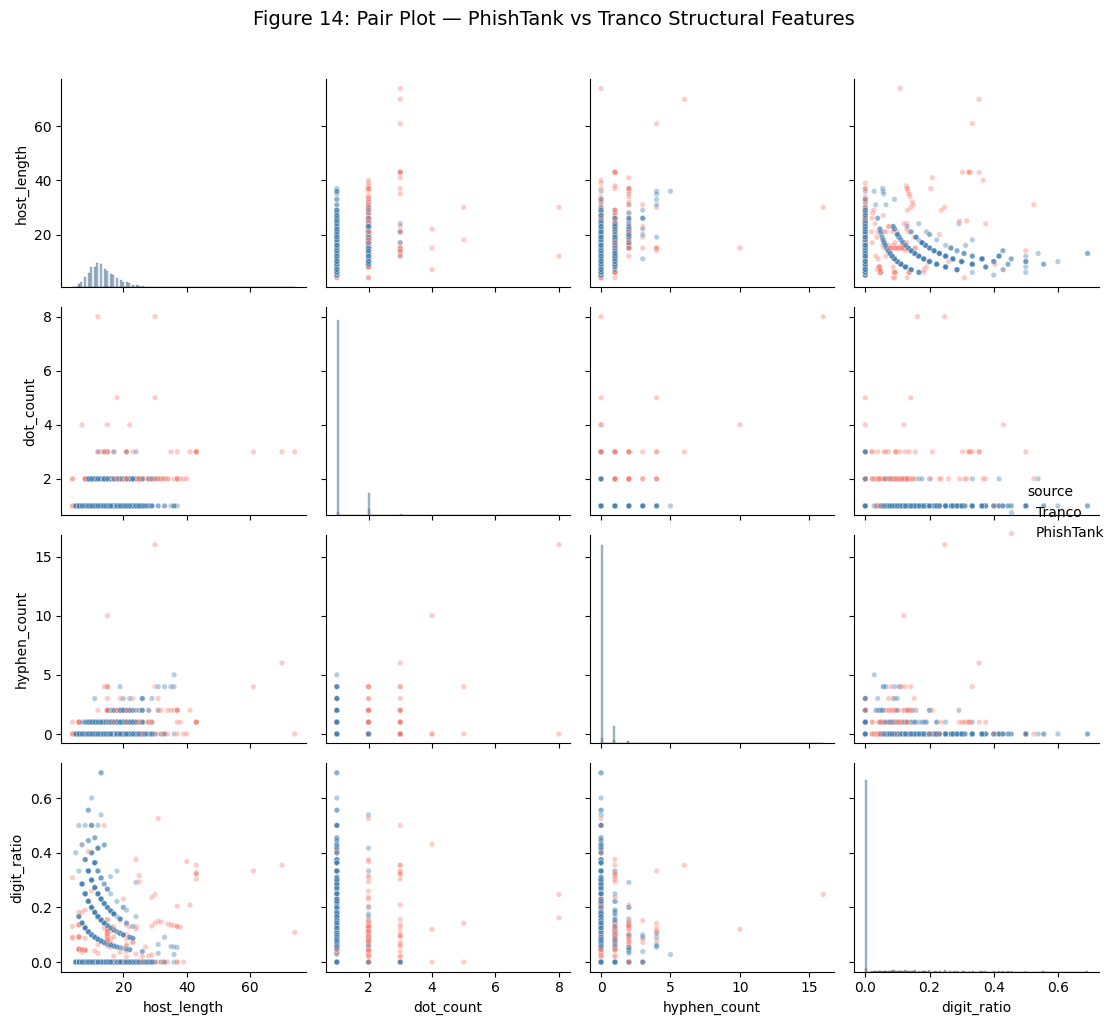

In [35]:
import numpy as np

# Build a combined dataframe with a 'source' label as a target variable
phish_sample = phish[['host_length', 'dot_count', 'hyphen_count', 'digit_ratio', 'subdomain_depth']].copy()
phish_sample['source'] = 'PhishTank'

tranco_sample = tranco[['domain_length', 'dot_count', 'hyphen_count', 'digit_ratio', 'subdomain_depth']].copy()
tranco_sample = tranco_sample.rename(columns={'domain_length': 'host_length'})
tranco_sample['source'] = 'Tranco'

combined = pd.concat([phish_sample, tranco_sample], ignore_index=True)

# Pair plot colored by dataset source
g = sns.pairplot(combined.sample(n=min(4000, len(combined)), random_state=42),
                 hue='source', vars=['host_length', 'dot_count', 'hyphen_count', 'digit_ratio'],
                 diag_kind='hist', plot_kws={'alpha': 0.4, 's': 15},
                 palette={'PhishTank': 'salmon', 'Tranco': 'steelblue'})
g.figure.suptitle('Figure 14: Pair Plot — PhishTank vs Tranco Structural Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Figure 14 — Interpretation:** The pair plot contrasts PhishTank and Tranco samples across key structural features. Clear separation is visible in several feature pairs, particularly URL length and subdomain depth, indicating that a linear or tree-based classifier should be able to leverage these features effectively for binary phishing detection.

## Data Normalization / Scaling
StandardScaler applied for future use for ML purposes.

In [36]:
from sklearn.preprocessing import StandardScaler

scale_features = ['full_length', 'host_length', 'path_depth', 'dot_count',
                  'hyphen_count', 'digit_ratio', 'subdomain_depth']

scaler = StandardScaler()
phish_scaled = pd.DataFrame(scaler.fit_transform(phish[scale_features]),
                            columns=[f'{c}_scaled' for c in
                                     scale_features])

phish_scaled.describe().round(2)

,full_length_scaled,host_length_scaled,path_depth_scaled,dot_count_scaled,hyphen_count_scaled,digit_ratio_scaled,subdomain_depth_scaled
count,56045.00,56045.00,56045.00,56045.00,56045.00,56045.00,56045.00
mean,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.29,-1.18,-0.88,-0.95,-0.57,-0.78,-1.32
25%,-0.23,-0.87,-0.88,-0.95,-0.57,-0.78,-1.32
50%,-0.14,-0.25,-0.24,0.02,-0.57,-0.31,0.40
75%,0.01,0.44,0.39,0.02,0.15,0.33,0.40
max,153.03,9.84,10.50,63.41,35.37,7.50,12.40


## Export Processed Datasets

In [37]:
phish.to_csv('../data/processed_input/phishtank_cleaned.csv', index=False)
tranco.to_csv('../data/processed_input/tranco_cleaned.csv', index=False)
print("Exported phishtank_cleaned.csv and tranco_cleaned.csv.")

Exported phishtank_cleaned.csv and tranco_cleaned.csv.


Success.

## Citations
[1] Gabriela Brezeanu, Alexandru Archip, and Codrut-Georgian Artene. Phish fighter: Self updating machine learning shield against phishing kits based on HTML code analysis. 13:4460–4486.

[2] Bibhu Dash and Meraj Farheen Ansari. An effective cybersecurity awareness training model: First defense of an organizational security strategy. International Research Journal of Engineering and Technology, 9:2395–0056, 04 2022.

[3] Dawn M. Sarno, Maggie W. Harris, and Jeffrey Black. Which phish is captured in the net? understanding phishing susceptibility and individual differences. 37(4):789–803._eprint:https://onlinelibrary.wiley.com/doi/pdf/10.1002/acp.4075.

[4] Giuseppe Desolda, Francesco Greco, and Luca Vigano. APOLLO: A GPT-based tool to detect phishing emails and generate explanations that warn users. 9(4):EICS003:1–EICS003:33.

[5] Nadjate Saidani, Kamel Adi, and Mohand Saïd Allili. A semantic-based classification approach for an enhanced spam detection. Computers & Security, 94, 2020-07.

[6] Sonowal and Gunikhan. Detecting phishing sms based on multiple correlation algorithms. SN Computer Science, 1, 11 2020.

[7] Panpan Zhang, Jing Ya, Tingwen Liu, Quangang Li, Jinqiao Shi, and Zhaojun Gu. imcircle: Automatic mining of indicators of compromise from the web. In 2019 IEEE  symposium on Computers and Communications (ISCC), 2019.

[8] Rasha Zieni, Luisa Massari, and Maria Carla Calzarossa. Phishing or not phishing? a survey on the detection of phishing websites. 11:18499–18519.

[9] Chugani, Vinod. “What Is Cosine Distance?” Datacamp.com, DataCamp, 28 July 2024, www.datacamp.com/tutorial/cosine-distance.

[10] Cisco Systems, Inc. PhishTank: Join the fight against phishing. phishtank.com, 2026.

[11] Victor Le Pochat, Tom Van Goethem, Samaneh Tajalizadehkhoob, Maciej Korczy´nski, and Wouter Joosen. Tranco: A Research-Oriented Top Sites Ranking Hardened Against Manipulation. In Proceedings of the 26th Annual Network and Distributed System Security Symposium (NDSS), 2019.